# Scatter Plot

In [1]:
import plotly.express as px

* >  x and y given as array_like objects

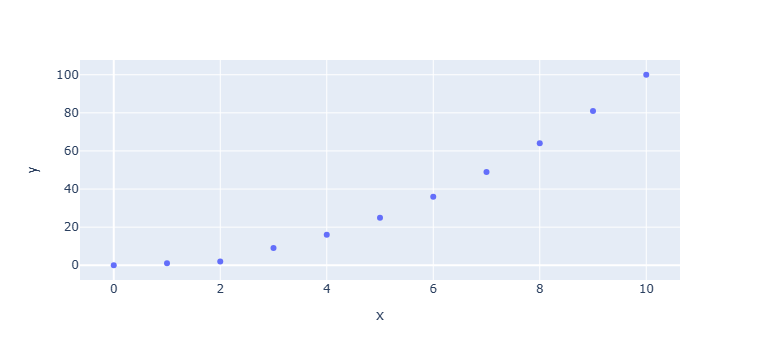

In [9]:
fig = px.scatter(x=[0,1,2,3,4,5,6,7,8,9,10],y=[0,1,2,9,16,25,36,49,64,81,100])
fig.show()

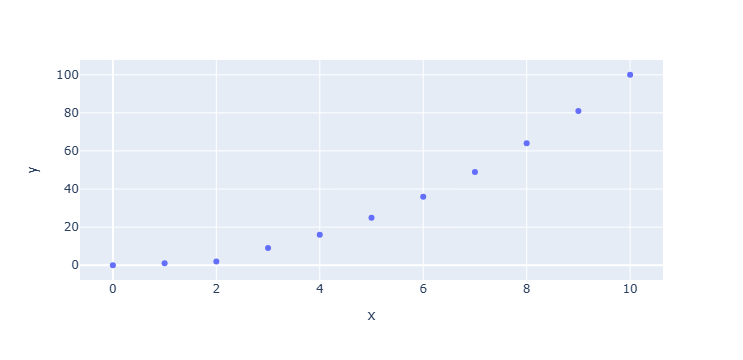

In [11]:
px.scatter(x=[0,1,2,3,4,5,6,7,8,9,10],y=[0,1,2,9,16,25,36,49,64,81,100])

* >  x and y given as DataFrame columns

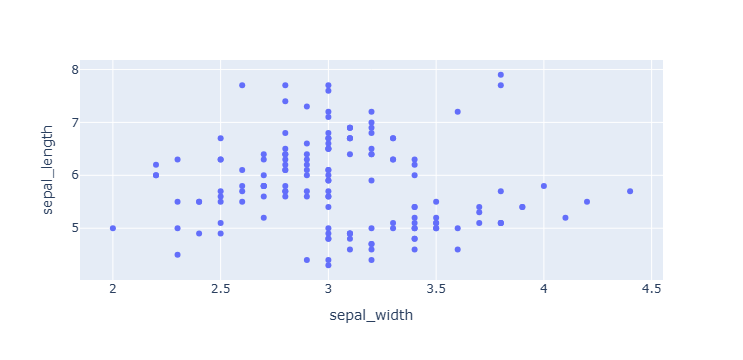

In [18]:
iris = px.data.iris()
fig = px.scatter(iris,x='sepal_width',y='sepal_length')
fig.show()

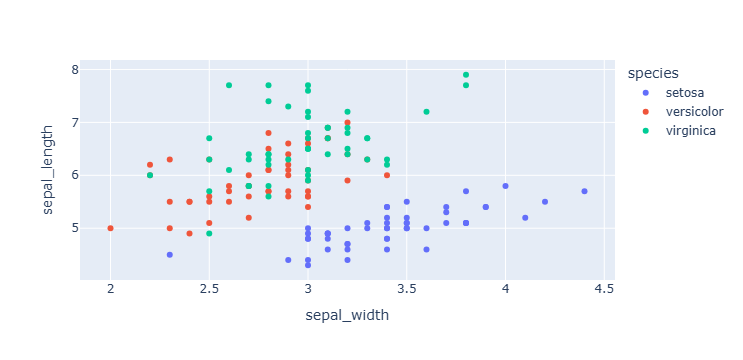

In [20]:
iris = px.data.iris()
fig = px.scatter(iris,x='sepal_width',y='sepal_length',
                color='species')
fig.show()

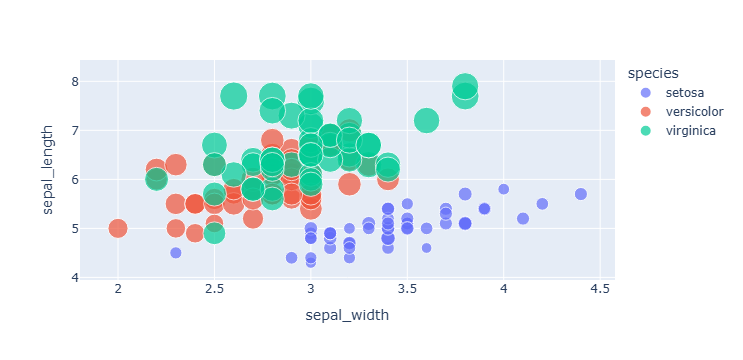

In [22]:
iris = px.data.iris()
fig = px.scatter(iris,x='sepal_width',y='sepal_length',
                color='species',size='petal_length')
fig.show()

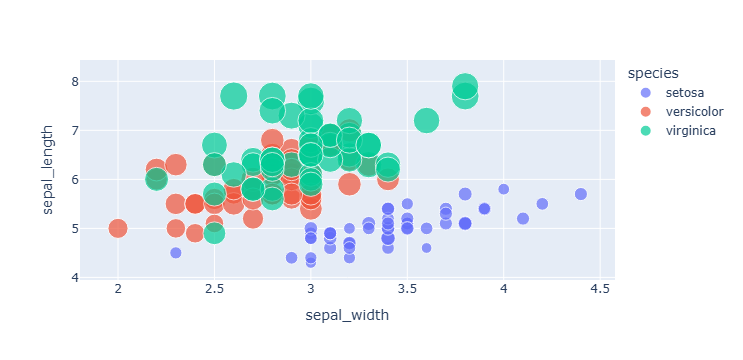

In [24]:
iris = px.data.iris()
fig = px.scatter(iris,x='sepal_width',y='sepal_length',
                color='species',size='petal_length',hover_data=['petal_width'])
fig.show()

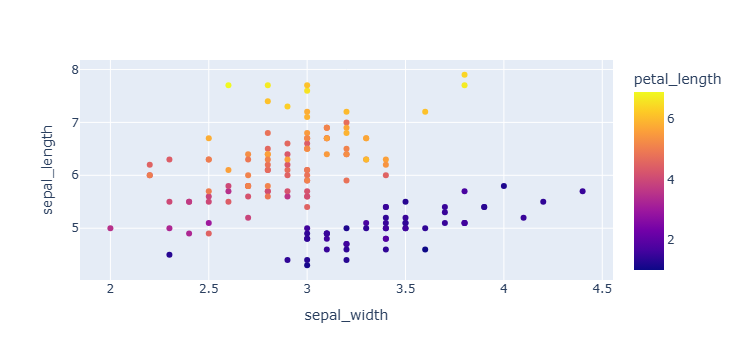

In [26]:
iris = px.data.iris()
fig = px.scatter(iris,x='sepal_width',y='sepal_length',
                color='petal_length')
fig.show()

The ``symbol`` argument can be mapped to a column as well. A wide variety of symbols are available.

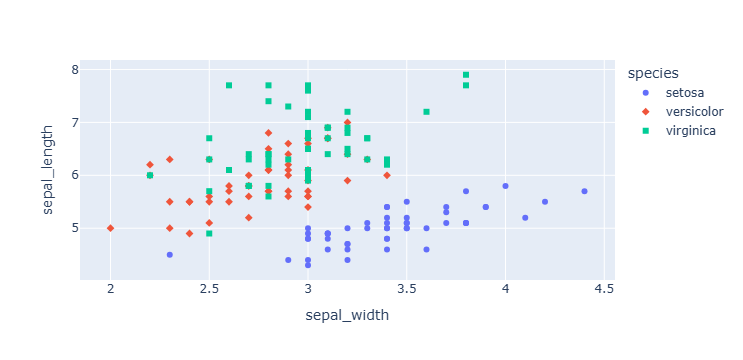

In [28]:
iris = px.data.iris()
fig = px.scatter(iris,x='sepal_width',y='sepal_length',
                color='species',symbol='species')
fig.show()

### Scatter Plot and Categorical Axis

In [33]:
df = px.data.medals_long()
df.head()

,nation,medal,count
0,South Korea,gold,24
1,China,gold,10
2,Canada,gold,9
3,South Korea,silver,13
4,China,silver,15


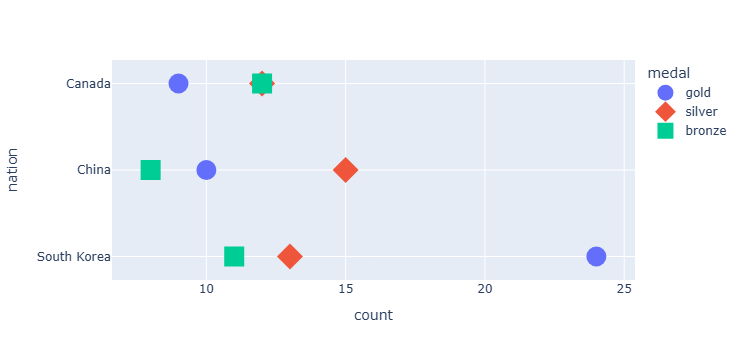

In [39]:
fig = px.scatter(df, x='count', y='nation', color='medal',symbol='medal')
fig.update_traces(marker_size=20)
fig.show()

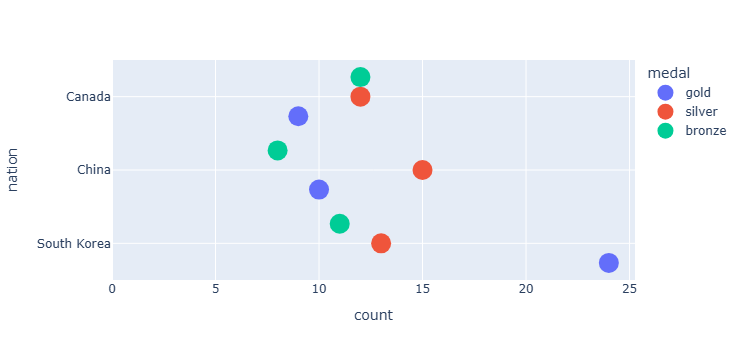

In [45]:
fig = px.scatter(df, x='count', y='nation', color='medal')
fig.update_traces(marker_size=20)
fig.update_layout(scattermode='group')
fig.show()

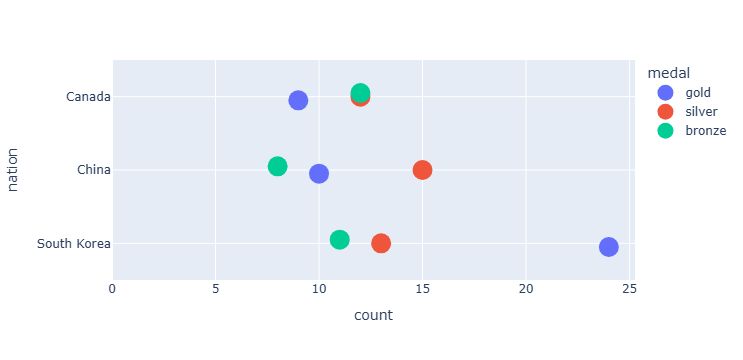

In [65]:
fig = px.scatter(df, x='count', y='nation', color='medal')
fig.update_traces(marker_size=20)
fig.update_layout(scattermode='group',scattergap=0.85)
fig.show()

### Error Bars

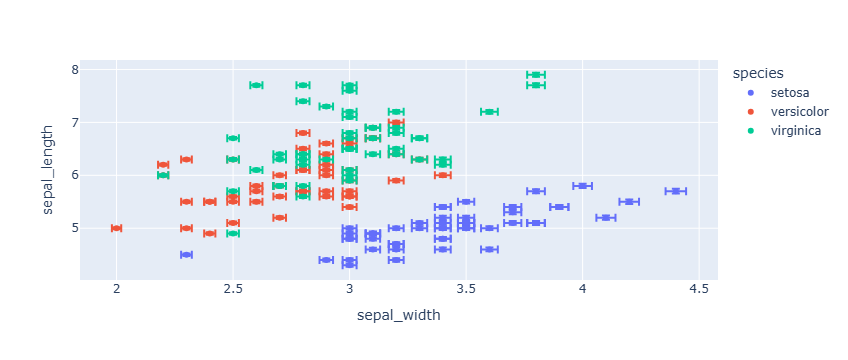

In [68]:
df = px.data.iris()
df['e'] = df['sepal_width']/100
fig = px.scatter(df, x='sepal_width', y='sepal_length', color='species',
                error_x='e',error_y='e')
fig.show()

### Margin Distribution Plots

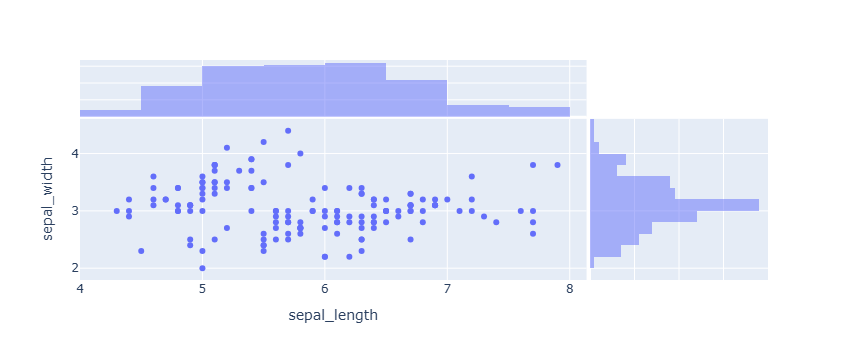

In [77]:
df = px.data.iris()
fig = px.scatter(df, x='sepal_length', y='sepal_width', marginal_x='histogram', marginal_y='histogram')
fig.show()

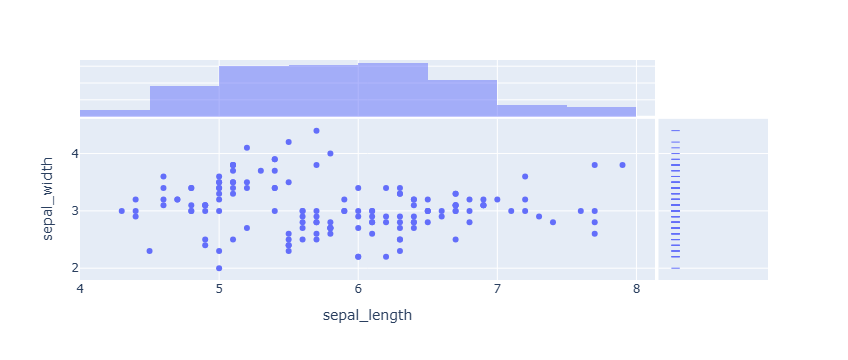

In [79]:
df = px.data.iris()
fig = px.scatter(df, x='sepal_length', y='sepal_width', marginal_x='histogram', marginal_y='rug')
fig.show()

## Facetting

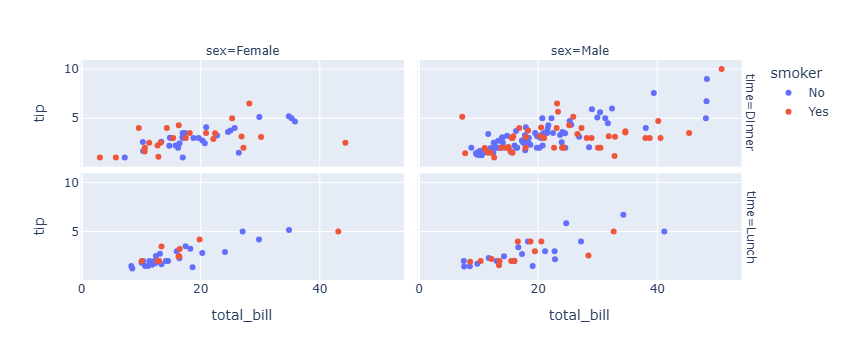

In [84]:
df = px.data.tips()
fig = px.scatter(df, x='total_bill',y='tip', color='smoker',facet_col='sex',facet_row='time',hover_name='day')
fig.show()

## Linear Regression and Other Trendlines

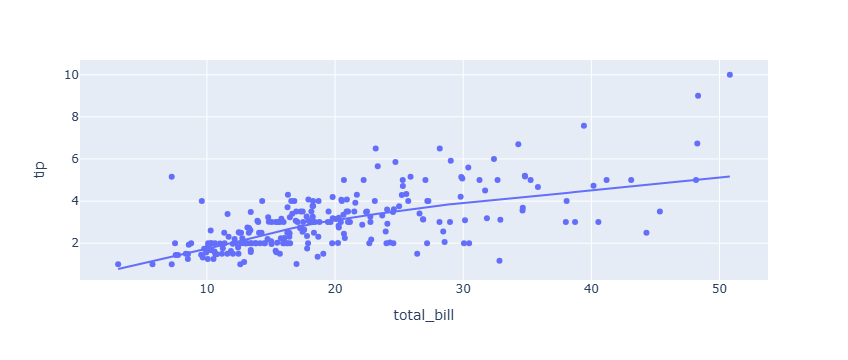

In [99]:
df = px.data.tips()
fig = px.scatter(df, x='total_bill', y='tip', trendline='lowess')
fig.show()

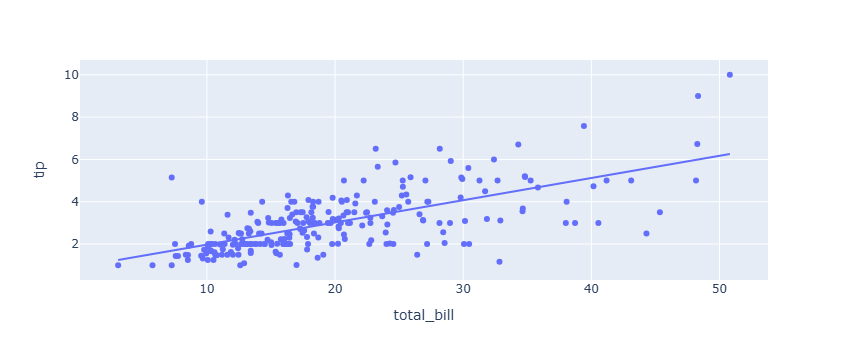

In [101]:
df = px.data.tips()
fig = px.scatter(df, x='total_bill', y='tip', trendline='ols')
fig.show()

# Line Plot

In [105]:
import numpy as np

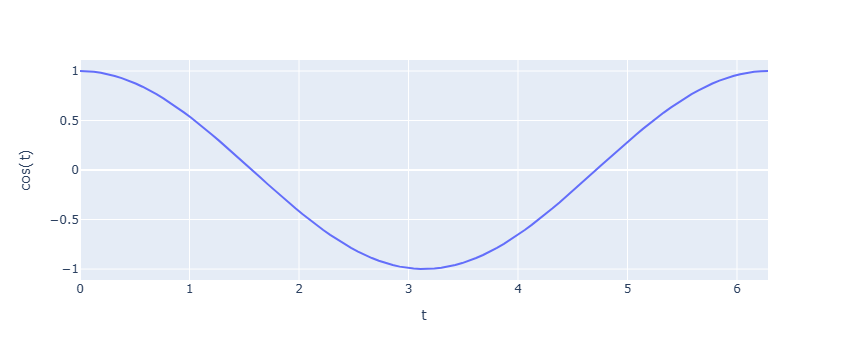

In [107]:
t = np.linspace(0,2*np.pi,100)
fig = px.line(x=t, y=np.cos(t), labels={'x':'t','y':'cos(t)'})
fig.show()

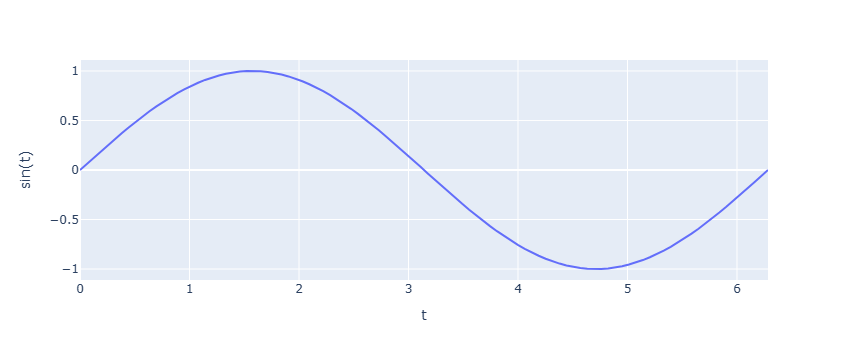

In [109]:
t = np.linspace(0,2*np.pi,100)
fig = px.line(x=t, y=np.sin(t), labels={'x':'t','y':'sin(t)'})
fig.show()

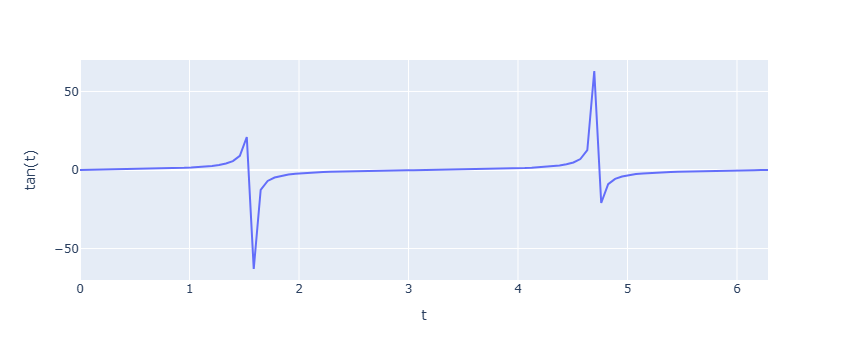

In [113]:
t = np.linspace(0,2*np.pi,100)
fig = px.line(x=t, y=np.tan(t), labels={'x':'t','y':'tan(t)'})
fig.show()

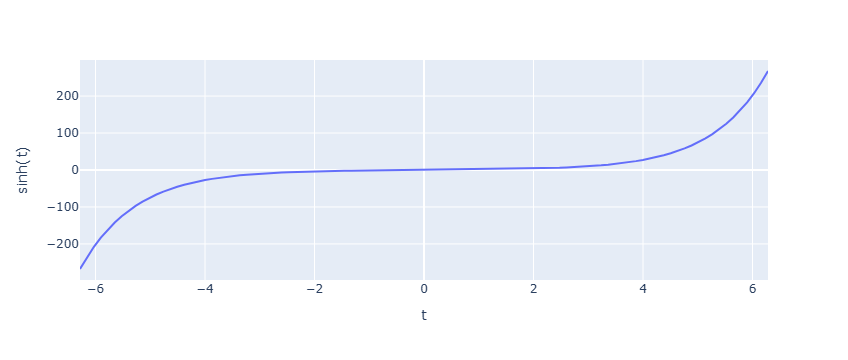

In [121]:
t = np.linspace(-2*np.pi,2*np.pi,100)
fig = px.line(x=t, y=np.sinh(t), labels={'x':'t','y':'sinh(t)'})
fig.show()

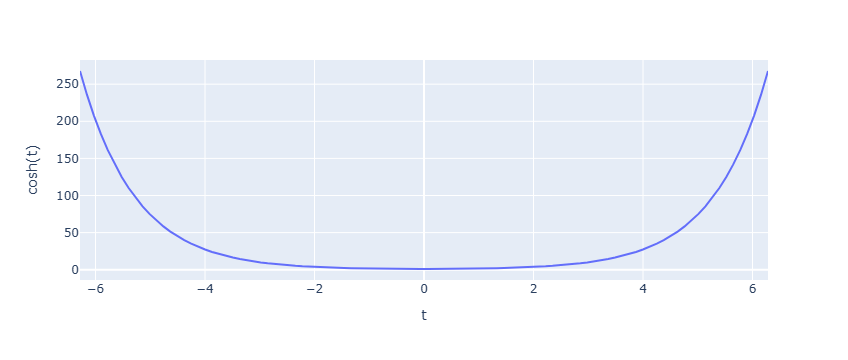

In [123]:
t = np.linspace(-2*np.pi,2*np.pi,100)
fig = px.line(x=t, y=np.cosh(t), labels={'x':'t','y':'cosh(t)'})
fig.show()

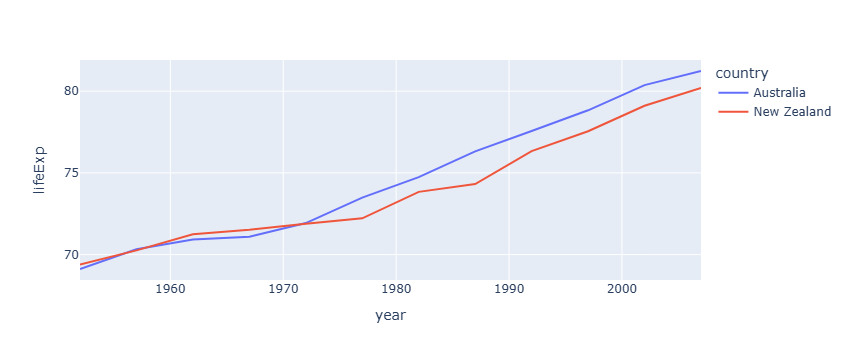

In [127]:
df = px.data.gapminder().query("continent=='Oceania'")
fig = px.line(df, x='year', y='lifeExp', color='country')
fig.show()

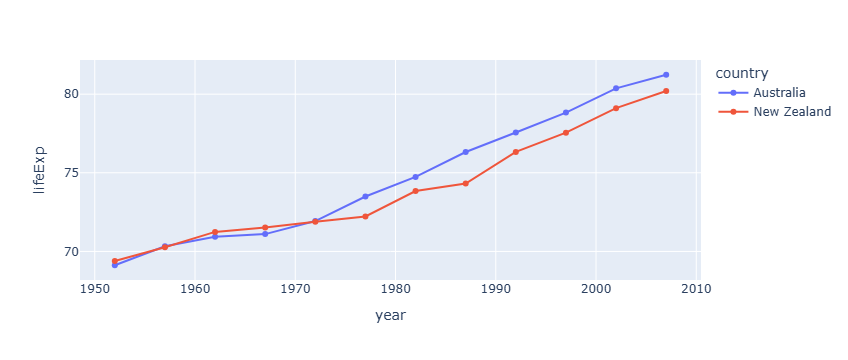

In [129]:
df = px.data.gapminder().query("continent=='Oceania'")
fig = px.line(df, x='year', y='lifeExp', color='country',markers=True)
fig.show()

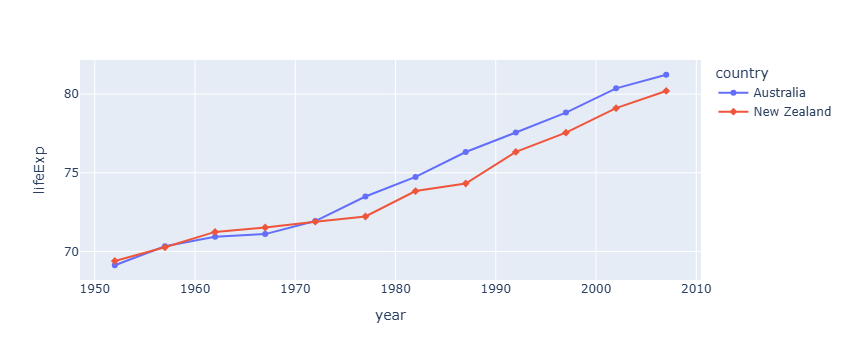

In [131]:
df = px.data.gapminder().query("continent=='Oceania'")
fig = px.line(df, x='year', y='lifeExp', color='country',symbol='country')
fig.show()

### Line plots on Date axes
* > Line plots can be made on using any type of cartesian axis, including `linear`, ``logarithmic``, ``categorical`` or ``date axes``. Line plots on date axes are often called ``time-series charts``.

* > Plotly auto-sets the axis type to a date format when the corresponding data are either ISO-formatted date strings or if they're a ``date pandas column`` or ``datetime NumPy array``.

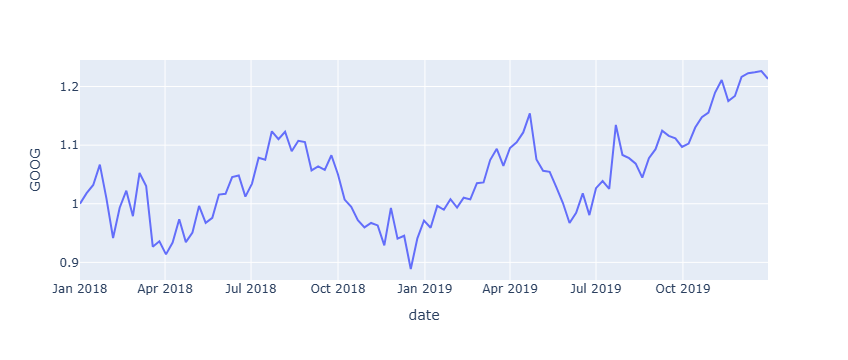

In [135]:
df = px.data.stocks()
fig = px.line(df, x='date',y='GOOG')
fig.show()

### Data Order in Scatter and Line Charts
* > Plotly line charts are implemented as connected scatterplots (see below), meaning that the points are plotted and connected with lines in the order they are provided, with no automatic reordering.

* > This makes it possible to make charts like the one below, but also means that it may be required to explicitly sort data before passing it to Plotly to avoid lines moving "backwards" across the chart.

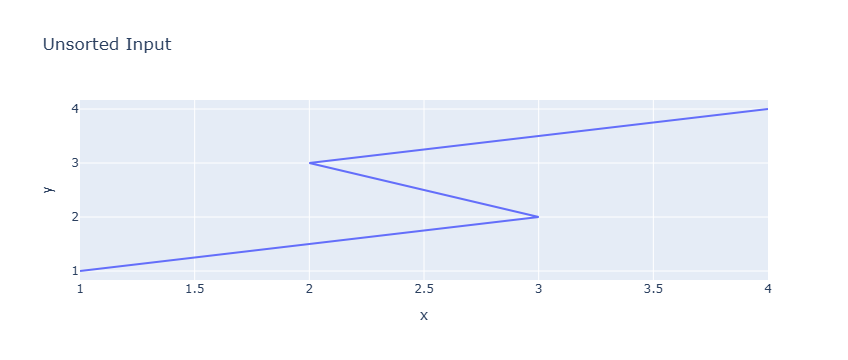

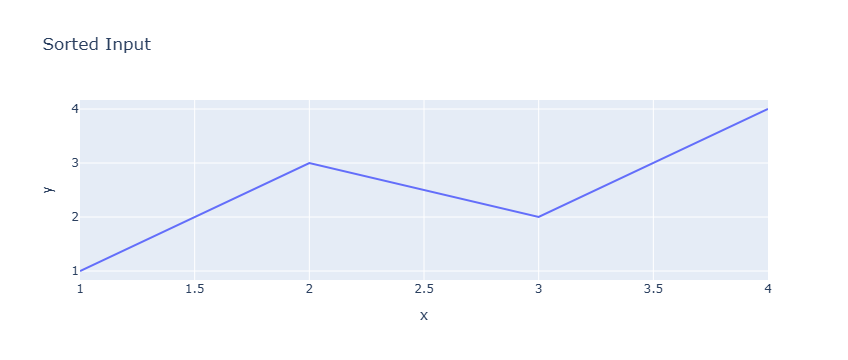

In [140]:
import pandas as pd
df = pd.DataFrame(dict(
    x = [1,3,2,4],
    y = [1,2,3,4]
))

fig = px.line(df, x='x', y='y', title='Unsorted Input')
fig.show()

df = df.sort_values(by='x')
fig = px.line(df, x='x', y='y', title='Sorted Input')
fig.show()

## Connected Scatterplot

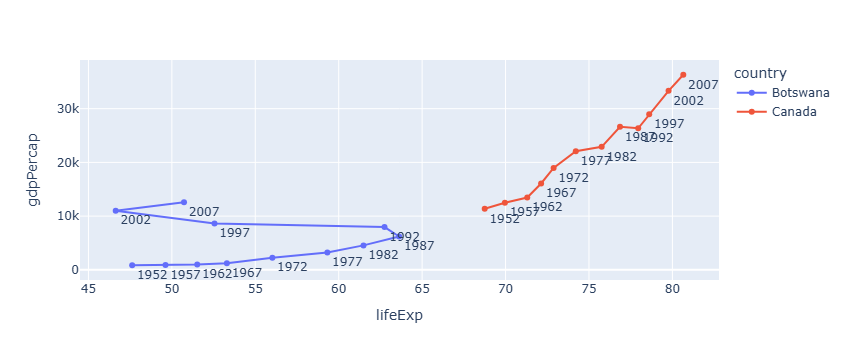

In [145]:
df = px.data.gapminder().query("country in ['Canada','Botswana']")

fig = px.line(df, x='lifeExp', y='gdpPercap', color='country', text='year')
fig.update_traces(textposition = 'bottom right')
fig.show()